# 02 · Transcripts, text features and the prompt shift

The heavy lifting runs as scripts with progress logs (they take 1–2 h on a laptop GPU):

| script | what it produces |
|---|---|
| `tools/extract_text.py` | two transcripts per clip and per crop, rate-based fluency features, GEC edit rates, CoLA acceptability, Qwen3-1.7B states + rubric score |
| `tools/extract_llm.py` | Qwen3-4B (4-bit) states on the error-preserving transcript |
| `tools/extract_textenc.py` | mean-pooled states of every layer of DeBERTa-v3-large, RoBERTa-large and ELECTRA-large |

This notebook reports what those features contain. Following the competition's data rules, it prints **no transcript text**, only statistics.

**Why two transcripts.** Whisper has a strong internal language model and tends to *repair* a learner's grammar ("he go" → "he goes"). For grammar scoring that hides exactly the signal we need. A wav2vec2 CTC recogniser decoded greedily, without a language model, writes what was said, errors included. Their disagreement is itself a feature.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from shl import metrics
OUT = ROOT / "artifacts"; TXT = OUT / "text"
sns.set_theme(style="whitegrid")
meta = pd.read_csv(OUT / "meta.csv")
hand = pd.read_csv(TXT / "hand.csv")
full = hand[hand.kind == "full"].set_index("uid").loc[meta.uid]
scorable = ((meta.split == "train") & (meta.label > 0)).values
y = meta.label.values[scorable]
print(f"{len(hand)} transcript items: {len(full)} full clips + {(hand.kind == 'crop').sum()} crops")

2523 transcript items: 985 full clips + 1538 crops


## 1 · What the transcript features say about grammar
Every feature is a **rate** (per word or per minute), because test clips are shorter than train clips and counts would encode length.

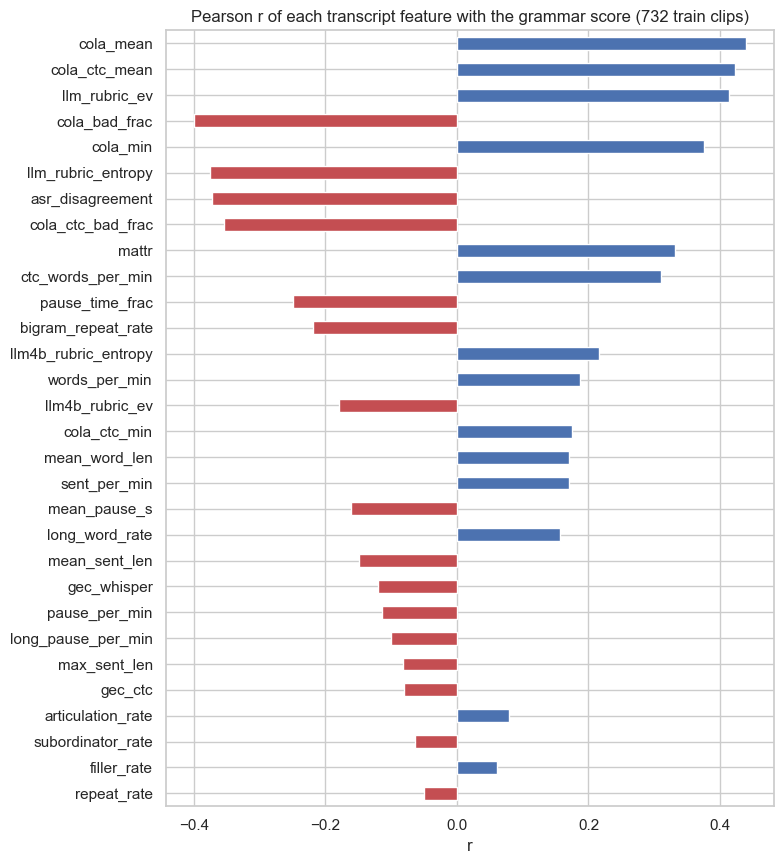

cola_mean             0.440
cola_ctc_mean         0.422
llm_rubric_ev         0.414
cola_bad_frac        -0.400
cola_min              0.376
llm_rubric_entropy   -0.375
asr_disagreement     -0.372
cola_ctc_bad_frac    -0.354
mattr                 0.332
ctc_words_per_min     0.311
dtype: float64

In [2]:
cols = [c for c in hand.columns if c not in ("kind", "uid", "crop_row", "duration_s")]
corr = pd.Series({c: metrics.pearson(y, full[c].values[scorable]) for c in cols}).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 0.26 * len(corr) + 1))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#4c72b0", "#c44e52")); ax.invert_yaxis()
ax.set(title="Pearson r of each transcript feature with the grammar score (732 train clips)", xlabel="r")
plt.tight_layout(); plt.show()
corr.round(3).head(10)

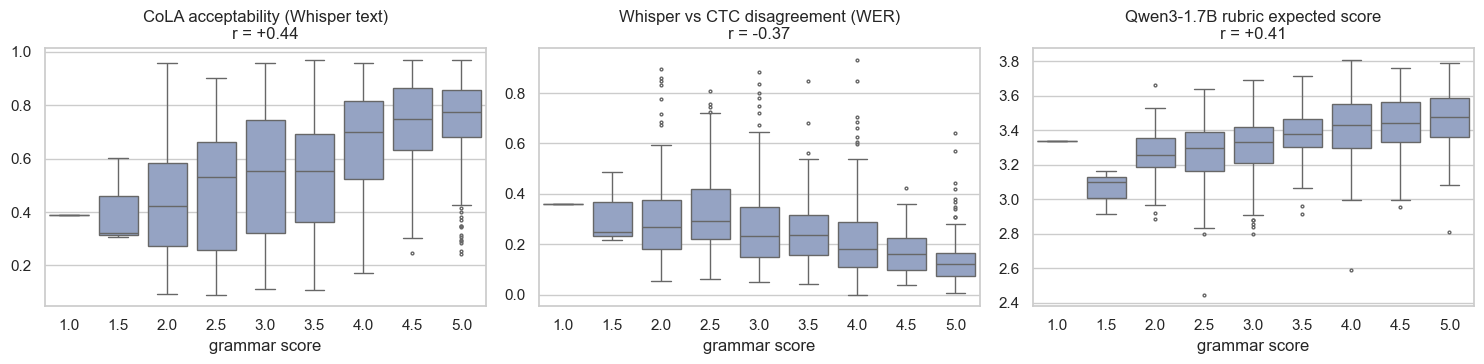

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c, t in zip(axes, ["cola_mean", "asr_disagreement", "llm_rubric_ev"],
                    ["CoLA acceptability (Whisper text)", "Whisper vs CTC disagreement (WER)", "Qwen3-1.7B rubric expected score"]):
    sns.boxplot(x=y, y=full[c].values[scorable], ax=ax, color="#8da0cb", fliersize=2)
    ax.set(title=f"{t}\nr = {metrics.pearson(y, full[c].values[scorable]):+.2f}", xlabel="grammar score")
plt.tight_layout(); plt.show()

Reading the plots:
- **Acceptability rises with the grade**: a RoBERTa model trained on the CoLA grammaticality corpus scores each sentence.
- **ASR disagreement falls with the grade**: where Whisper and the CTC recogniser disagree more, Whisper is often quietly correcting errors.
- **A zero-shot LLM rubric score already carries signal** (r ≈ 0.41). It is used as a feature, not as the predictor.

## 2 · The prompt shift
Transcripts were clustered into topics (TF-IDF → SVD → k-means, unsupervised, train and test together). Two topics that are almost absent from train dominate the test set. This was the key to making cross-validation match the leaderboard: folds now hold out **speakers and prompts** (`folds_joint.csv`).

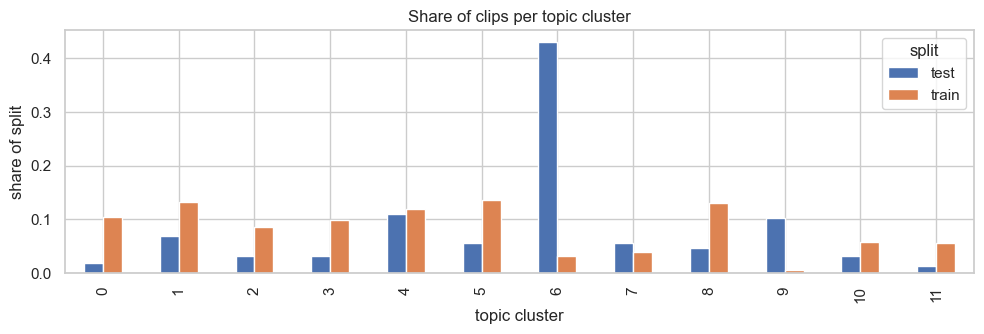

prompt,0,1,2,3,4,5,6,7,8,9,10,11
split,,,,,,,,,,,,
test,1.9,6.9,3.2,3.2,11.1,5.6,43.1,5.6,4.6,10.2,3.2,1.4
train,10.4,13.3,8.6,10.0,12.0,13.7,3.1,4.0,13.0,0.7,5.7,5.6


In [4]:
pc = pd.read_csv(OUT / "prompt_clusters.csv"); pc["split"] = pc.uid.str.split("/").str[0]
share = pd.crosstab(pc.prompt, pc.split, normalize="columns")
fig, ax = plt.subplots(figsize=(10, 3.5)); share.plot.bar(ax=ax)
ax.set(title="Share of clips per topic cluster", xlabel="topic cluster", ylabel="share of split"); plt.tight_layout(); plt.show()
(share * 100).round(1).T

| topic | share of test | share of train |
|---|---|---|
| "free time / family / friends" (cluster 6) | **43%** | 3% |
| "floods" (cluster 9) | **10%** | 1% |

Consequence for model selection: views that encode *what an answer is about* lose accuracy on unseen prompts. Under speaker+prompt held-out CV, Qwen3 states lose ~0.03, audio views < 0.01. The final stack and blend weight views by how well they transfer, not by in-distribution CV.